<a href="https://colab.research.google.com/github/CatelloVivenzio/real_estate_ai_solutions/blob/main/RealEstateAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto: RealEstateAI Solutions
## Un modello di previsione per il mercato immobiliare

**Autore:** Catello Vivenzio<br>
**Data:** 15 Marzo 2026<br>
**Versione:** 1.0

### Obiettivi
* Fornire un modello per una previsione di prezzo accurata e affidabile.
* Riduzione del rischio di overfitting.
* Migliorare la generalizzazione del modello

> Note: analisi sul dataset https://www.google.com/url?q=https%3A%2F%2Fproai-datasets.s3.eu-west-3.amazonaws.com%2Fhousing.csv

# Importazione delle librerie

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Caricamento dei dati

In [ ]:
# Impostazione di un 'seme' per replicabilita' dei test
RANDOM_SEED = 2
URL_FILE = "https://proai-datasets.s3.eu-west-3.amazonaws.com/housing.csv"
# Caricamento del file tramite la libreria 'pandas' dentro un oggetto DataFrame
df = pd.read_csv(URL_FILE)
# Ritorna le prime 5 righe del DataFrame
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1


# Dimensione dei dati

In [ ]:
# Ritorna una tupla con il numero di righe e colonne
df.shape

(545, 13)

#Verifica dei tipi di dati

---



In [ ]:
# Ritorna un sommario sulle variabili del DataFrame
# con anche l'informazione sul tipo di dato di ogni colonna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


Dalle informazioni si nota che non sono presenti campi nulli e che ogni colonna e' di tipo intero.

#Analisi statistica dei dati

In [ ]:
# Setting per mostrare i dati senza notazione scientifica
pd.set_option('display.float_format', '{:.0f}'.format)
# Ritorna un sommario di dati statistici del DataFrame
# - Numero di osservazioni - Media - Devizione Standard
# - Valore Minimo - Percentili: 25% 50% 75% - Valore Massimo
df.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,545,545,545,545,545,545,545,545,545,545,545,545,545
mean,4766729,5151,3,1,2,1,0,0,0,0,1,0,1
std,1870440,2170,1,1,1,0,0,0,0,0,1,0,1
min,1750000,1650,1,1,1,0,0,0,0,0,0,0,0
25%,3430000,3600,2,1,1,1,0,0,0,0,0,0,0
50%,4340000,4600,3,1,2,1,0,0,0,0,0,0,1
75%,5740000,6360,3,2,2,1,0,1,0,1,1,0,2
max,13300000,16200,6,4,4,1,1,1,1,1,3,1,2


Si nota che per la colonna target **price**, il valore massimo raggiunge **13.300.000,00** che supera il triplo della media dei valori. Questo lascia presupporre la presenza di outlier.

#Analisi dei dati: **outliers**

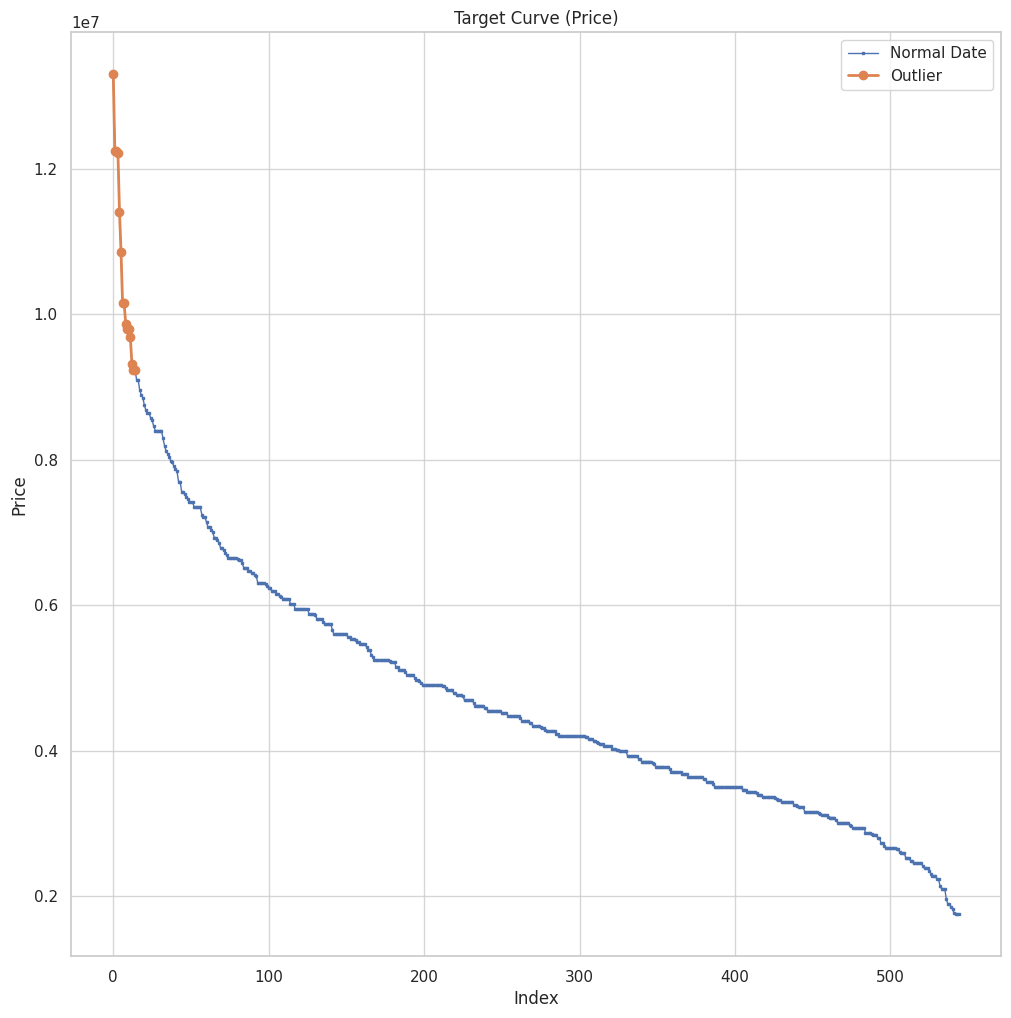

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,2
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,2
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,1
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0


In [ ]:
# Identificazione IQR - centro della distribuzione sulla varibile target
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
# 1.5 e' un moltiplicatore standard per identificare valori anomali
# Rappresenta una distanza di sicurezza moltiplicata per l'ampiezza
# dell'interquartile che separa i dati 'normali' da quelli 'anomali'
threshold = 1.5
low_bound = Q1 - threshold * IQR
up_bound = Q3 + threshold * IQR
# Estrae dal DataFrame gli outlier ossia quelli minori di
# low_bound oppure maggiori di up_bound
outliers = df[(df['price'] < low_bound) | (df['price'] > up_bound)]
# Setta le dimensioni della figura
plt.figure(figsize=(12, 12))
# Disegna una curva con tutti i valori della variabile target 'price' marcati
plt.plot(
    df.index, df['price'],
    marker='s',
    label='Normal Date',
    linewidth=1,
    markersize=2
)
# Disegna una curva con tutti i valori 'outliers' marcati
plt.plot(
    outliers.index,
    outliers['price'],
    marker='o',
    label='Outlier',
    linewidth=2
)
# Label per asse X
plt.xlabel('Index')
# Label asse Y
plt.ylabel('Price')
# Titolo del grafico
plt.title('Target Curve (Price)')
# Mostra la legenda
plt.legend()
# Mostra la griglia
plt.grid(True, which="both", ls="-", alpha=0.8)
# Mostra tutto il grafico
plt.show()
outliers

In [ ]:
outliers_percentage = (outliers.shape[0]/df.shape[0])*100
print(f"Outliers percentage: {outliers_percentage:.2f}%")

Outliers percentage: 2.75%


Dalle analisi risulta una percentuale dell'2.75% di valori fuori scala superiori al valore limite superiore, che in numeri rappresentano 15 osservazioni (**outliers**).

#Controllo valori mancanti

In [ ]:
# Re setting delle opzioni di formattazione
pd.reset_option('display.float_format')
# Conteggio dei valori nulli
missing_count = df.isna().sum()
print(f"Count missing value: \n{missing_count}")

Count missing value: 
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


La verifica mostra l'assenza di valori mancanti (come anche visto in precedenza sulle informazioni) sia per le osservazioni sia per la varibile target per cui non e' necessario effettuare eventuali rimozioni e/o imputazioni.

#Analisi dominio dei dati

In [ ]:
# Conta il numero di elementi distinti per l'asse
# specificato (di default 0 le righe)
df.nunique()

,0
price,219
area,284
bedrooms,6
bathrooms,4
stories,4
mainroad,2
guestroom,2
basement,2
hotwaterheating,2
airconditioning,2


La verifica mostra che le variabili sono correttamente codificate per cui non e' necessario effettuare eventuali operazioni di feature encoding.

#Correlazione tra i dati: **matrice di correlazione**

<Axes: >

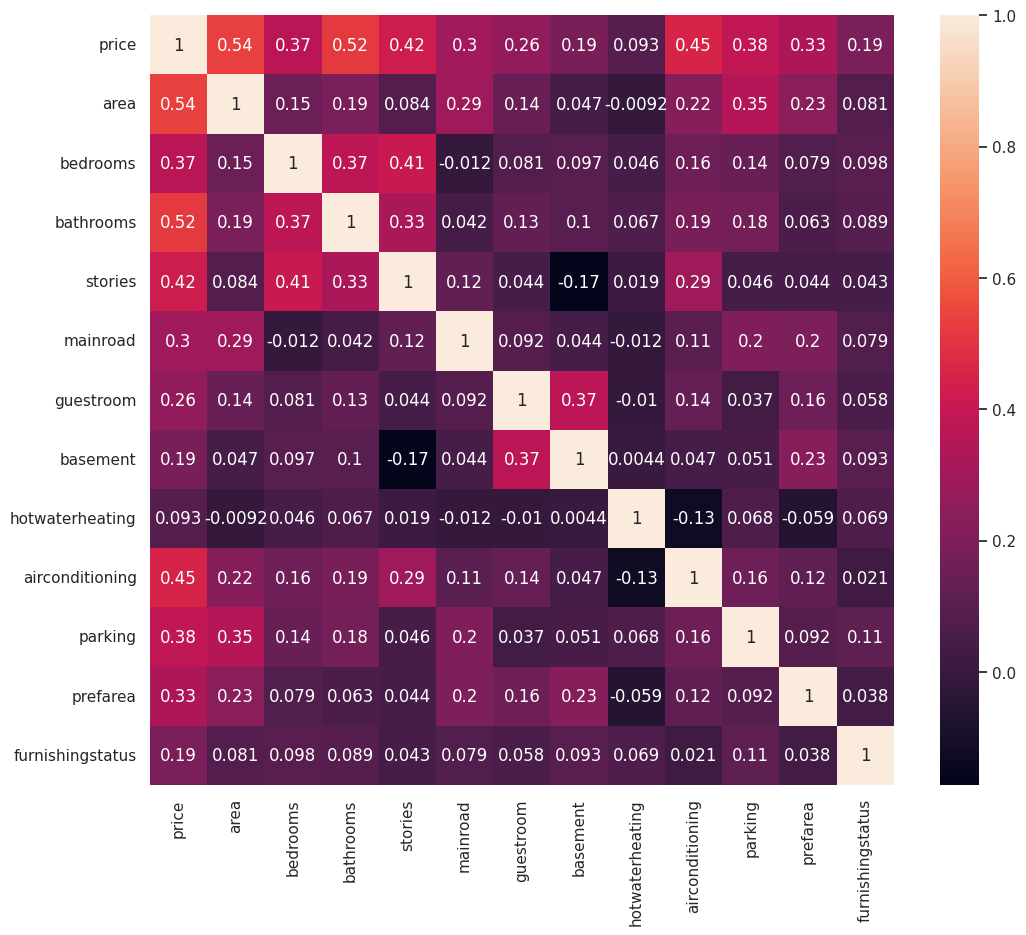

In [ ]:
# Setta le dimensioni della figura
plt.figure(figsize=(12, 10))
# Tramite la libreria 'seaborn' e il metodo 'corr' di pandas sul DataFrame
# visualizza agevolmente una matrice che mostra le correlazioni tra i dati
sns.heatmap(df.corr(), annot=True)

L'analisi della matrice di correlazione mostra che il prezzo ossia la colonna target **price** e' trainata principalmente dalla dimensione dell'immobile ossia **area** e dal numero di bagni **bathrooms**.
Le variabili strutturali **stories**, **airconditioning** prevalgono sui servizi come **hotwaterhearting** nella determinazione del valore. Non si riscontrano problemi di multicollinearita' critica tra le variabili predittive (feature), ossia altamente collegate tra loro, ognuna contribuisce con peso differente al valore finale.

# Variabili predittive: **feature**

In [ ]:
target_col = "price"
X = df.drop(columns=[target_col], axis=1)
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,1
1,8960,4,4,4,1,0,0,0,1,3,0,1
2,9960,3,2,2,1,0,1,0,0,2,1,2
3,7500,4,2,2,1,0,1,0,1,3,1,1
4,7420,4,1,2,1,1,1,0,1,2,0,1


# Variabile dipendente: **target**

In [ ]:
y = df[target_col]
y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


# Metodo per la valutazione del modello: **Hold-out method**

**Hold-out method**: valuteremo i modelli con questo processo che consiste nella divisione del dataset per valutare la capacita' di generalizzazione del modello.
Addestriamo l'algoritmo su una parte dei dati il **Training Set** e poi lo proviamo su dati che non ha mai visto il **Test Set**.
**Hold-out Method** indica infatti una porzione di dati che viene **tenuta fuori** (**hold-out**) per la validazione finale.


In [ ]:
# Dati: 70% per addestramento - 30% per test
# Utilizziamo queste percentuali vista anche la dimensione dele osservazioni
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    shuffle=True,
    random_state=RANDOM_SEED
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 381
Test samples: 164


Il risultato mostra che 381 saranno le osservazioni per addestrare il modello mentre 164 tenute per eseguire il test.

## Pre Processing: **Standard Scaler**
Dalle analisi sui dati, **area** risulta dominante come dominio di valori rispetto alle altre variabili, per cui il modello potrebbe associargli un peso maggiore a scapito di altre, cosi' scegliamo di usare un processo di **Standardizzazione**, portando i dati su una scala comune con **media = 0** e **deviazione standard = 1**. Questa inoltre e' piu' indicata quando siamo in presenza di outliers in quanto non tende a **'schiacciare'** i dati.



In [ ]:
# Inizializza lo scaler
ss = StandardScaler()
# Fit-Trasform sul set dei dati per addestramento
X_train = ss.fit_transform(X_train)
# Trasform sul set dei dati per test
X_test = ss.transform(X_test)

X_train.shape

(381, 12)

In [ ]:
type(y_train)

pandas.core.series.Series

# Metodo per la valutazione dei modelli

In [ ]:
def evaluate_model(x_tr, x_t, y_tr, y_t, model, alphas, ratio=None):

    """
    Metodo per addestramento, predizione e calcolo delle metriche per modelli
    di regolarizzazione Ridge, Lasso e Elastic Net.

    Per ogni valore dell'iperparametro 'alpha', il metodo addestra il modello,
    esegue la predizione sul set di test e calcola le metriche, aggiungendo
    i dati dentro un array in forma di dizionario.

    Args:
        x_tr (object): numpy.ndarray con i valori delle feature per il set di
                       addestramento.
        x_t (object):  numpy.ndarray con i valori delle feature per il set di
                       test.
        y_tr (object): pandas.core.series.Series con i valori della variabile
                       target per il set di addestramento.
        y_t (object): pandas.core.series.Series con i valori della variabile
                       target per il set di test.
        model (object): il modello di regolarizzazione.
        alphas (object): array[float] con i valori per ipermparametro alpha.
        ratio (float, optional): valore per il parametro 'l1_ratio' nel caso di
                                 regolarizzazione Elastic Net, default None.

    Returns:
        object: ritorna un array[dict] con i seguenti valori calcolati
                su ogni valore dell'iperparametro alpha contenuto in alphas:
                - Il valore corrente di alpha.
                - Il  numero di coefficienti che il modello sta utilizzando.
                - Il valore di R2 score sul set di addestramento.
                - Il valore di R2 score sul set di test.
                - Il valore del Mean Squared Error sul set di test
                - Il valore del Root Mean Squared Error sul set di test


    """

    # Array dove andranno aggiunti i risultati
    summary = []
    for a in alphas:
        # Imposta i parametri al modello
        if ratio:
            # Caso Elastic Net
            model = model.set_params(**{
                'alpha':a,
                'l1_ratio':ratio,
                'random_state':RANDOM_SEED
            })
        else:
            model = model.set_params(**{
                'alpha':a,
                'random_state':RANDOM_SEED
            })
        # Addestramento
        model.fit(x_tr, y_tr)
        # Predizione sul set di test
        y_t_pr = model.predict(x_t)
        # Calcolo delle funzioni di costo
        mse_test = mean_squared_error(y_t, y_t_pr)
        rmse_test = np.sqrt(mse_test)
        # Calcolo dello score su set di addestramento
        r2_train = model.score(x_tr, y_tr)
        # Calcolo dello score su set di test
        r2_test = model.score(x_t, y_t)
        # Aggiunge i dati calcolati come dizionario all'array dei risultati
        summary.append({
            'Alpha': a,
            'Coeff.': sum(model.coef_ != 0),
            'R2 Train': f"{r2_train:.4f}",
            'R2 Test': f"{r2_test:.4f}",
            'MSE Test': f"{mse_test:.2f}",
            'RMSE Test ($)': f"{rmse_test:.2f}"
        })
    return (summary, model)

# Regolarizzazione 1: **Ridge (L2)**
La **Ridge Regression (regolarizzazione L2)** aggiunge una **penalita'** al quadrato dei coefficienti. L'obiettivo e' **'rimpicciolire'** i pesi delle feature meno importanti senza pero' azzerarli del tutto, rendendo il modello piu' stabile.


In [ ]:
# Valori dell'iperparametro alpha (lambda) per Ridge
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
# Richiama la funzione di valutazione del modello per Ridge
summary_ridge, model_ridge = evaluate_model(
    X_train,
    X_test,
    y_train,
    y_test,
    Ridge(),
    alphas
)
# DataFrame riassuntivo dei risultati
df_summary_ridge = pd.DataFrame(summary_ridge)
print(f"--- RIDGE ---")
df_summary_ridge

--- RIDGE ---


,Alpha,Coeff.,R2 Train,R2 Test,MSE Test,RMSE Test ($)
0,0.01,12,0.6870,0.6570,1260757357856.73,1122834.52
1,0.10,12,0.6870,0.6570,1260763912949.25,1122837.44
2,1.00,12,0.6870,0.6570,1260833807363.22,1122868.56
3,10.00,12,0.6868,0.6567,1261944650743.75,1123363.10
4,100.00,12,0.6780,0.6463,1300086269281.68,1140213.26
5,1000.00,12,0.4903,0.4599,1985144858661.18,1408951.69


Dalle analisi dei risultati, **Ridge** ha il risultato migliore su **alpha=0.01** con un **R2=0.6870** sul set di addestramento e **R2=0.6570** sul set di test con **RMSE=1.122.834,52**.
Fino al valore di **alpha=100.0** mantiene una certa stabilita' crollando poi sul valore **alpha=1000.0**.

# Regolarizzazione 2: **Lasso (L1)**
La **Lasso Regression** ha come caratteristica quella di poter **azzerare** i coefficienti delle feature meno importanti portando il loro peso a 0.

In [ ]:
# Valori dell'iperparametro alpha (lambda) per Lasso
# Rispetto ai valori per Ridge, abbiamo il valore massimo per alpha
# che arriva a 162000.0 in quanto dai test effettuati rappresenta il valore
# su cui Lasso azzera il primo coefficiente
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0, 150000.0, 162000.0]
summary_lasso, model_lasso = evaluate_model(
    X_train,
    X_test,
    y_train,
    y_test,
    Lasso(),
    alphas
)
# DataFrame riassuntivo dei risultati
df_summary_lasso = pd.DataFrame(summary_lasso)
print("--- LASSO ---")
df_summary_lasso

--- LASSO ---


,Alpha,Coeff.,R2 Train,R2 Test,MSE Test,RMSE Test ($)
0,0.01,12,0.6870,0.6570,1260756636191.55,1122834.20
1,0.10,12,0.6870,0.6570,1260756650476.35,1122834.20
2,1.00,12,0.6870,0.6570,1260756778303.79,1122834.26
3,10.00,12,0.6870,0.6570,1260758350341.20,1122834.96
4,100.00,12,0.6870,0.6570,1260775351352.24,1122842.53
5,1000.00,12,0.6870,0.6569,1260935928896.33,1122914.03
6,10000.00,12,0.6868,0.6563,1263139441938.76,1123894.76
7,100000.00,12,0.6693,0.6341,1344948332512.89,1159719.07
8,150000.00,12,0.6472,0.6089,1437358171116.30,1198898.73
9,162000.00,11,0.6406,0.6016,1464410627339.50,1210128.35


Dalle analisi dei risultati, **Lasso** ottiene il risultato migliore su **alpha=0.01** con un **R2=0.6870** sul set di addestramento e **R2=0.6570** sul set di test con **RMSE=1.122.834,20**.
Fino al valore di **alpha=10000.0** mantiene una certa stabilita' crollando poi sul valore **alpha=100000.0**. Il primo coefficiente portato a zero dall'algoritmo e' su **alpha=162.000.0**.

# Modello 3: **Elastic Net**
**Elastic Net** e' un metodo ibrido che combina le penalità di **Lasso (L1)** e **Ridge (L2)**. Regolarizza i coefficienti utilizzando una somma ponderata delle penalita' di **L1** e **L2**.

In [ ]:
# Valori dell'iperparametro alpha (lambda) per Elastic Net
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
summary_en, model_en = evaluate_model(
    X_train,
    X_test,
    y_train,
    y_test,
    ElasticNet(),
    alphas,
    ratio=0.5
)
# DataFrame riassuntivo
df_summary_en = pd.DataFrame(summary_en)
print("--- ELASTIC NET ---")
df_summary_en

--- ELASTIC NET ---


,Alpha,Coeff.,R2 Train,R2 Test,MSE Test,RMSE Test ($)
0,0.01,12,0.6870,0.6569,1260911972255.68,1122903.37
1,0.10,12,0.6865,0.6562,1263746889141.60,1124164.97
2,1.00,12,0.6617,0.6290,1363510996047.19,1167694.74
3,10.00,12,0.3662,0.3413,2420934679442.68,1555935.31
4,100.00,12,0.0605,0.0544,3475416937639.24,1864247.02
5,1000.00,12,0.0064,0.0042,3660093145815.54,1913136.99


Dalle analisi dei risultati, **Elastic Net** ottiene il risultato migliore su **alpha=0.01** con **ratio** equilibrato a **0.5** quindi bilanciato su pari peso tra **L1** e **L2**.
I risultati ottenuti sono un **R2=0.6870** sul set di addestramento e un **R2=0.6569** sul set di test con **RMSE=1.122.903,37**.
Fino al valore di **alpha=1.0** mantiene una certa stabilita' crollando dal valore **alpha=10.0**.

# Grafico sugli andamenti delle regolarizzazioni

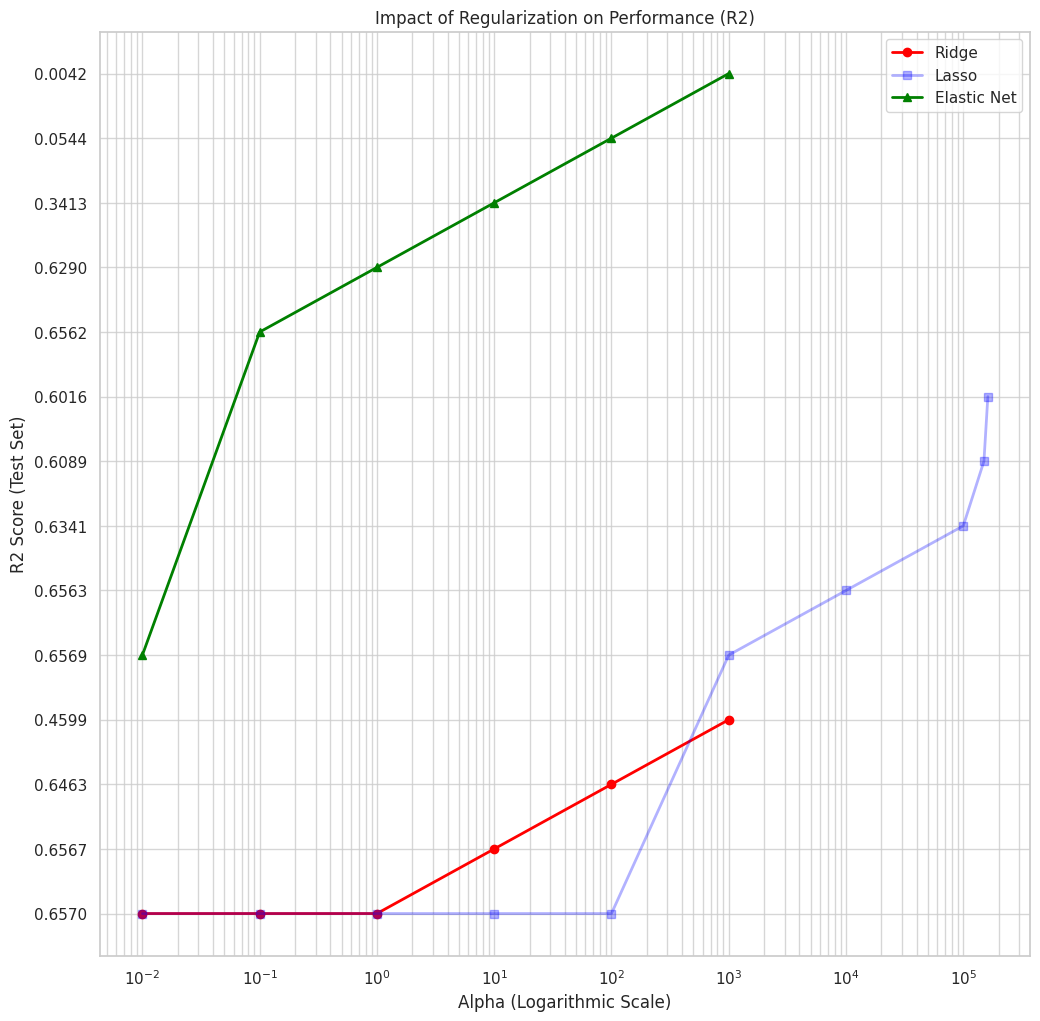

In [ ]:
plt.figure(figsize=(12, 12))
# Plot Ridge
plt.plot(
    df_summary_ridge['Alpha'],
    df_summary_ridge['R2 Test'],
    marker='o',
    label='Ridge',
    linewidth=2,
    color='red'
)
# Plot Lasso
plt.plot(
    df_summary_lasso['Alpha'],
    df_summary_lasso['R2 Test'],
    marker='s',
    label='Lasso',
    linewidth=2,
    color='blue',
    alpha=0.3
)
# Plot Elastic Net
plt.plot(
    df_summary_en['Alpha'],
    df_summary_en['R2 Test'],
    marker='^',
    label='Elastic Net',
    linewidth=2,
    color='green'
)
# Scala logaritmica necessaria per gestire il range
# dell'iperparametro alpha (lambda) diverso per i modelli
plt.xscale('log')
plt.xlabel('Alpha (Logarithmic Scale)')
plt.ylabel('R2 Score (Test Set)')
plt.title('Impact of Regularization on Performance (R2)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.8)
plt.show()


# Grafici Bar Plot sulle metriche

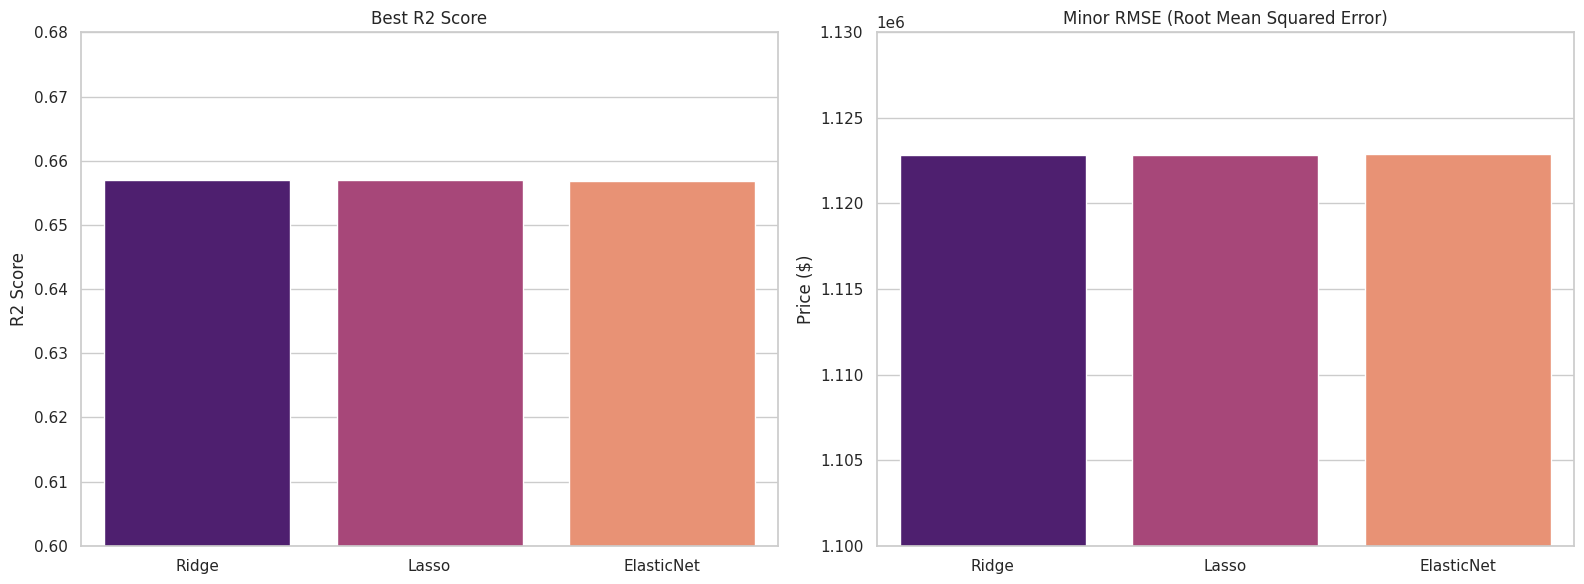

In [ ]:
# Copie per non sporcare i DataFrame originali
plot_ridge = df_summary_ridge.copy()
plot_lasso = df_summary_lasso.copy()
plot_en = df_summary_en.copy()
# Trasforma i risultati dai DataFrame come float
for df in [plot_ridge, plot_lasso, plot_en]:
    df['R2 Test'] = df['R2 Test'].astype(float)
    df['RMSE Test ($)'] = df['RMSE Test ($)'].astype(float)
model_names = ['Ridge', 'Lasso', 'ElasticNet']
# Recupero dei migliori valori per lo score il Max R2
r2_scores = [
    plot_ridge['R2 Test'].max(),
    plot_lasso['R2 Test'].max(),
    plot_en['R2 Test'].max()
]
# Recupero dei migliori valori per il costo il Min RMSE
rmse_scores = [
    plot_ridge['RMSE Test ($)'].min(),
    plot_lasso['RMSE Test ($)'].min(),
    plot_en['RMSE Test ($)'].min()
]
# Valori di setting per i grafici
sns.set_theme(style="whitegrid")
# Per mostrare 2 grafici uno accanto all'altro
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Grafico 1 per il confronto di R2
sns.barplot(
    x=model_names,
    y=r2_scores,
    hue=model_names,
    legend=False,
    ax=axes[0],
    palette='magma'
)
axes[0].set_title('Best R2 Score')
# Range mostrare differenze piccole
axes[0].set_ylim(0.60, 0.68)
axes[0].set_ylabel('R2 Score')
# Grafico 2 per il confronto sull'errore RMSE
sns.barplot(
    x=model_names,
    y=rmse_scores,
    hue=model_names,
    legend=False,
    ax=axes[1],
    palette='magma'
)
axes[1].set_title('Minor RMSE (Root Mean Squared Error)')
# Range asse y per mostrare le differenze
axes[1].set_ylim(1100000, 1130000)
axes[1].set_ylabel('Price ($)')
# Regolazione automatica della spaziatura
plt.tight_layout()
plt.show()

#Grafici dei residui

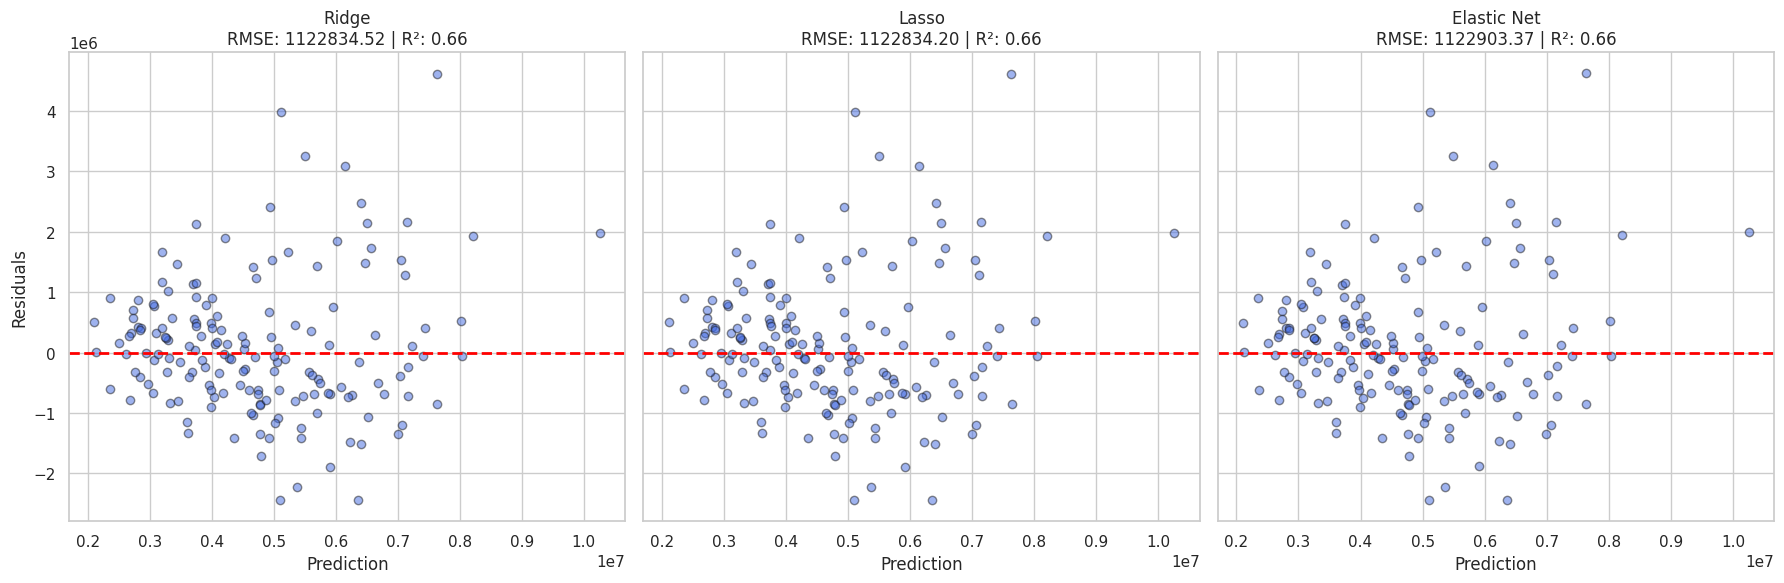

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
# Prepariamo i modelli con i valori che hanno ottenuto i migliori risultati
models = [
    Ridge(alpha=0.01, random_state=RANDOM_SEED),
    Lasso(alpha=0.01, random_state=RANDOM_SEED),
    ElasticNet(alpha=0.01, random_state=RANDOM_SEED, l1_ratio=0.5)
]
names = ["Ridge", "Lasso", "Elastic Net"]
for i, model in enumerate(models):
    # Addestramento e predizione
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Conversione per numpy
    y_t = np.array(y_test).flatten()
    y_p = np.array(y_pred).flatten()
    # Calcolo dei residui
    residuals = y_t - y_p
    # Calocolo dell metriche
    mse = mean_squared_error(y_t, y_p)
    r2 = r2_score(y_t, y_p)
    # Grafico
    axes[i].scatter(y_p, residuals, alpha=0.5, c='royalblue', edgecolors='k')
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=2)
    # Titolo con i valori delle metriche
    axes[i].set_title(f"{names[i]}\nRMSE: {np.sqrt(mse):.2f} | R²: {r2:.2f}")
    axes[i].set_xlabel("Prediction")
    if i == 0: axes[i].set_ylabel("Residuals")
plt.tight_layout()
plt.show()


# R2 Score: Ridge vs Lasso

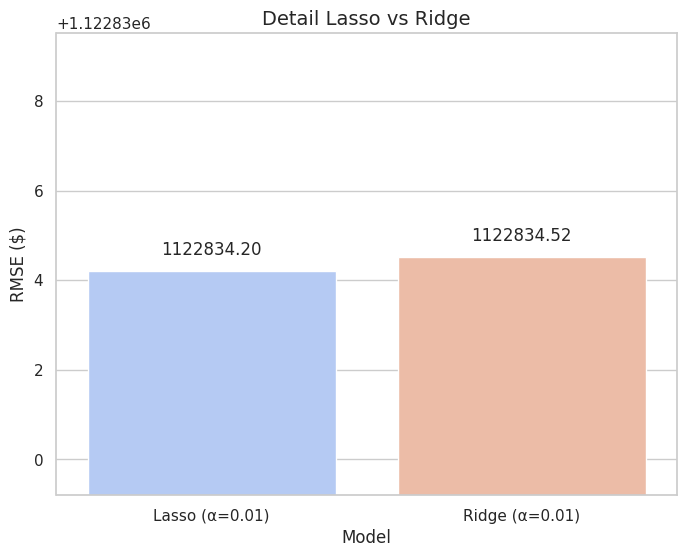

In [ ]:
# Recupero dei migliori risultati dai DataFrame
lasso_rmse = df_summary_lasso['RMSE Test ($)'].astype(float).min() #1122834.20
ridge_rmse = df_summary_ridge['RMSE Test ($)'].astype(float).min() #1122834.52
# Crea un DataFrame da dizionario
models = pd.DataFrame({
    'Model': ['Lasso (α=0.01)', 'Ridge (α=0.01)'],
    'RMSE Test ($)': [lasso_rmse, ridge_rmse]
})
# Grafico a barre con zoom sull'errore per evidenziare la differenza
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    x='Model',
    y='RMSE Test ($)',
    data=models,
    palette='coolwarm',
    hue='Model',
    legend=False
)
# Imposta limiti per asse y per poter visualizzare meglio
# la differenza tra Lasso e Ridge essendo molto sottile
min_val = lasso_rmse - 5
max_val = ridge_rmse + 5
plt.ylim(min_val, max_val)
plt.title('Detail Lasso vs Ridge', fontsize=14)
plt.ylabel('RMSE ($)')
# Aggiunta etichette precise sopra i bar plot
ax.bar_label(ax.containers[0], fmt='%.2f', padding=9)
ax.bar_label(ax.containers[1], fmt='%.2f', padding=9)
plt.show()

# Considerazioni finali
Modello migliore risulta **Lasso** che
 ha ottenuto l'errore quadratico medio più basso con **RMSE = 1.122.834,20**.<br>
 **Ridge** si scosta di una frazione minima con **RMSE = 1.122.834,52**.<br>
 Entrambi hanno lo stesso risultato come score con **R2 = 0.6870** sul set di addestramento e un **R2 = 0.6570** sul set di test.<br>
La complessita' nonostante la regolarizzazione e' rimasta pressoche' invariata e sui valori di **alpha** comuni ad entrambi, i modelli hanno mantenuto **12 coefficienti non nulli**, dove con **Lasso** il primo coefficiente nullo si e' ottenuto con **alpha = 162000.0** .<br>
Questo ci indica che tutte le feature fornite nel dataset hanno un valore informativo rilevante per la determinazione del prezzo e nessuna e' risultata totalmente ridondante.<br>
Riguardo la stabilita', la differenza trascurabile tra le performance di **Ridge** e **Lasso** con parametri di penalita' bassi ci suggerisce che il dataset non soffre di multicollinearita' estrema, rendendo la regressione lineare standard abbastanza solida.<br>
Interpretando i dati con **R2 score** di **0.657** sul set di test ci indica che il modello riesce a spiegare il **65.7%** della **varianza dei prezzi degli immobili**.